In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('crop_yield.csv')

In [3]:
df.sample(5)

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
11931,Sannhamp,2010,Kharif,Jammu and Kashmir,156.0,88,1352.0000,2.591316e+04,37.44,0.645000
14075,Wheat,2014,Rabi,Uttar Pradesh,9846466.0,20054791,616.4000,1.486423e+09,3249333.78,2.065467
10910,Horse-gram,2008,Kharif,Uttarakhand,9531.0,7419,1363.7000,1.363314e+06,857.79,0.749091
1432,Ginger,2003,Kharif,Puducherry,187.0,156,1434.5875,1.850926e+04,44.88,0.565000
17136,Ragi,2019,Kharif,Telangana,1488.0,2355,1031.7000,2.555789e+05,550.56,1.644286


In [4]:
df.shape

(19689, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [6]:
up_data = df[df['State'] == 'Uttar Pradesh'].copy()

In [7]:
up_data.sample(5)

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
9990,Linseed,2006,Rabi,Uttar Pradesh,33759.0,11855,590.5,4311361.89,7426.98,0.325217
7022,Small millets,1999,Kharif,Uttar Pradesh,239361.0,300468,883.4,25403382.93,64627.47,0.843818
10888,Potato,2008,Rabi,Uttar Pradesh,527347.0,10809926,891.6,75431714.88,47461.23,18.973429
7840,Tobacco,2001,Whole Year,Uttar Pradesh,19772.0,134679,849.9,2019314.36,5140.72,6.335926
16545,Small millets,2018,Summer,Uttar Pradesh,63.0,57,792.8,10218.60,22.05,0.950000


In [8]:
up_data.shape

(825, 10)

In [9]:
up_data = up_data.dropna(subset=['Production', 'Area'])
up_data = up_data[up_data['Area'] > 0]

In [10]:
up_data['Yield'] = up_data['Production'] / up_data['Area']

In [11]:
numerical_cols = ['Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']

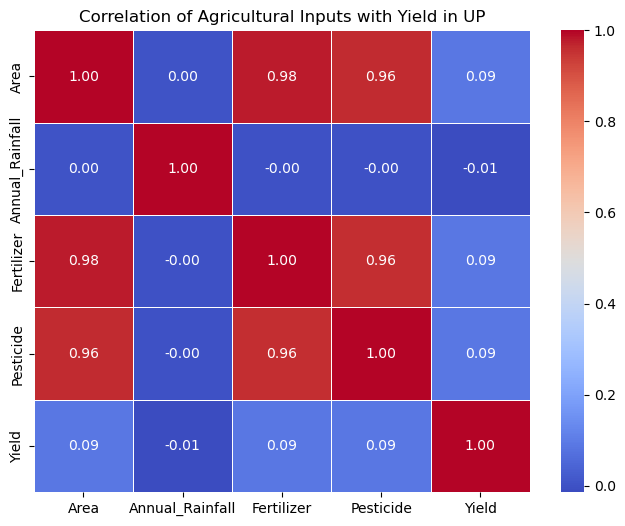

In [12]:
available_cols = [col for col in numerical_cols if col in up_data.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(up_data[available_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation of Agricultural Inputs with Yield in UP')
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16916\901052341.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crops.values, y=top_crops.index, palette='viridis')


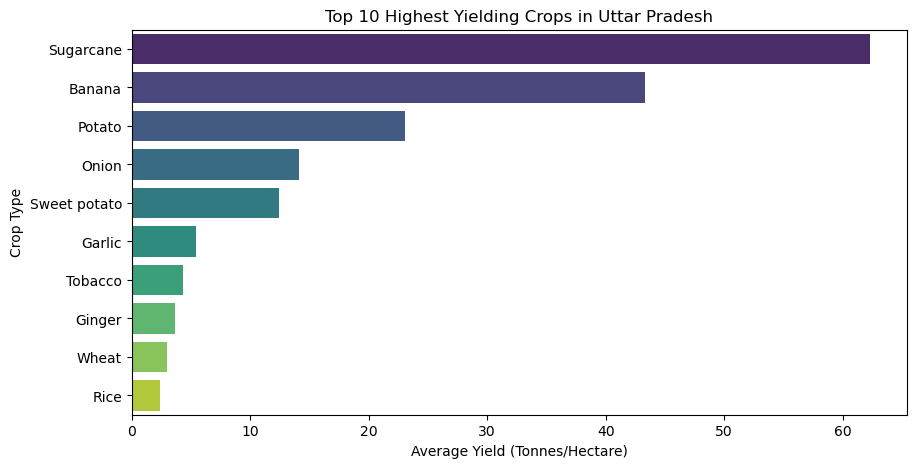

In [13]:
top_crops = up_data.groupby('Crop')['Yield'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_crops.values, y=top_crops.index, palette='viridis')
plt.title('Top 10 Highest Yielding Crops in Uttar Pradesh')
plt.xlabel('Average Yield (Tonnes/Hectare)')
plt.ylabel('Crop Type')
plt.show()

In [14]:
Q1 = up_data['Yield'].quantile(0.25)
Q3 = up_data['Yield'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [15]:
up_data_clean = up_data[(up_data['Yield'] >= lower_bound) & (up_data['Yield'] <= upper_bound)].copy()

In [16]:
scaler = StandardScaler()
features_to_scale = [col for col in ['Annual_Rainfall', 'Fertilizer', 'Pesticide'] if col in up_data_clean.columns]

if features_to_scale:
    up_data_clean[features_to_scale] = scaler.fit_transform(up_data_clean[features_to_scale])

In [17]:
model_data = up_data_clean.drop(['Area', 'Production', 'State'], axis=1)


In [18]:
categorical_cols = [ 'Season', 'Crop']
encoded_data = pd.get_dummies(model_data, columns=categorical_cols, drop_first=True)


In [19]:
X = encoded_data.drop('Yield', axis=1)
y = encoded_data['Yield']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [21]:
predictions = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

In [22]:
print("-" * 40)
print("FINAL MODEL PERFORMANCE")
print(f"RMSE: {rmse:.4f} Tonnes/Hectare")
print(f"R-squared: {r2:.4f}")
print("-" * 40)

----------------------------------------
FINAL MODEL PERFORMANCE
RMSE: 0.2808 Tonnes/Hectare
R-squared: 0.9389
----------------------------------------


<Axes: xlabel='Yield'>

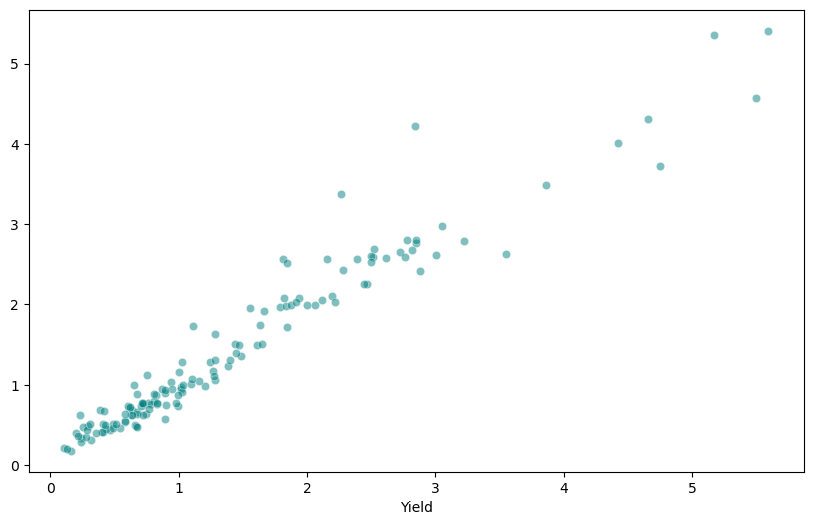

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.5, color='teal')

In [25]:
import joblib

print("Saving model for deployment...")

# Save the trained model
joblib.dump(rf_model, 'crop_rf_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save the exact columns the model expects
joblib.dump(X.columns, 'model_columns.pkl')


Saving model for deployment...


['model_columns.pkl']